# Part 2 — Stationarity & Decomposition

**PyTimeSeries user guide** · *Diagnostics with statsmodels; pytimeseries focuses on the modeling that follows.*

> Uses the `pytimeseries` package on the shared commodity-price dataset.

In [1]:
import warnings; warnings.simplefilter("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import pytimeseries as pt
plt.rcParams.update({"figure.figsize": (10, 3.8), "axes.grid": True, "grid.alpha": .3,
                     "axes.spines.top": False, "axes.spines.right": False})

# Shared dataset: 356 months of global commodity prices (1992-2021)
raw = pd.read_csv("monthly_price.csv")
dates = pd.to_datetime(raw["YEAR"].astype(str) + "-" + raw["MONTH"], format="%Y-%b")
df = raw.drop(columns=["ID", "YEAR", "MONTH", "TIME"]); df.index = dates
df.index.name = "date"; df = df.asfreq("MS")
y = df["Food_Price_Index"]
print("pytimeseries", pt.__version__, "| series:", list(df.columns))

pytimeseries 0.5.0 | series: ['Urea_Price', 'MP_Price', 'TSP_Price', 'Maize_Price', 'Rice_Price', 'Wheat_Price', 'Food_Price_Index', 'Energy_Price_Index', 'VIX_Index']


`pytimeseries` deliberately leaves pure diagnostics to `statsmodels`. This part shows the stationarity check and STL decomposition that motivate the models.

In [2]:
from statsmodels.tsa.stattools import adfuller
p_raw = adfuller(y.dropna())[1]; p_diff = adfuller(y.diff().dropna())[1]
print(f'ADF p-value  raw={p_raw:.3f}  differenced={p_diff:.3f}  -> difference once')

ADF p-value  raw=0.609  differenced=0.000  -> difference once


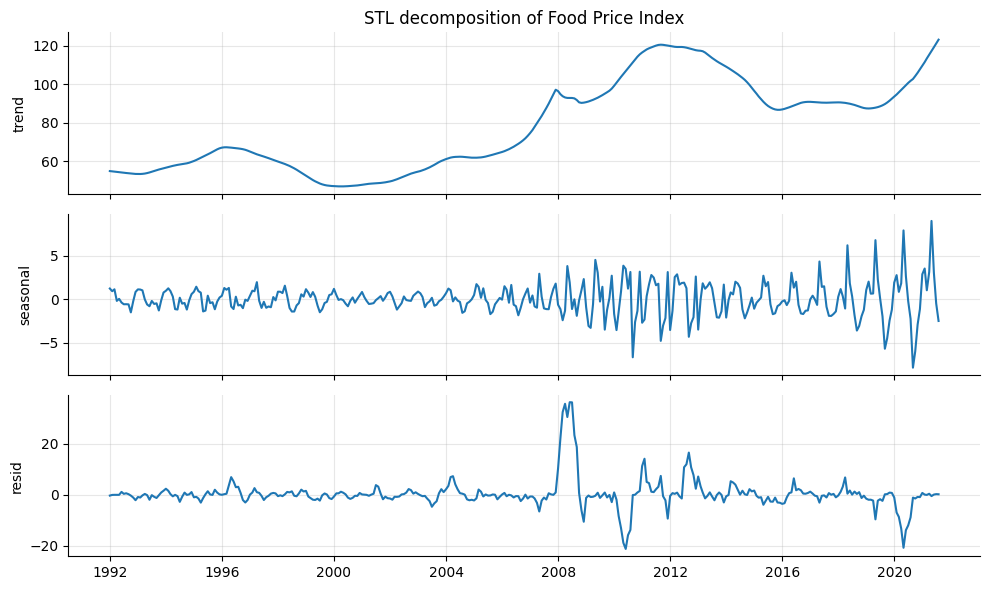

In [3]:
from statsmodels.tsa.seasonal import STL
res = STL(y, period=12, robust=True).fit()
fig, ax = plt.subplots(3, 1, figsize=(10, 6), sharex=True)
ax[0].plot(res.trend); ax[0].set_ylabel('trend')
ax[1].plot(res.seasonal); ax[1].set_ylabel('seasonal')
ax[2].plot(res.resid); ax[2].set_ylabel('resid')
ax[0].set_title('STL decomposition of Food Price Index'); plt.tight_layout(); plt.show()

**Takeaway.** The series is non-stationary (trend) with light seasonality — a profile the ETS and ARIMA models in Parts 3-4 handle directly.